In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Callable, NamedTuple

from msmjax.bspline_basis import create_bspline_basis_element

In [2]:
ORDER = 3
# ORDER = 1   # TODO: does this order correspond to p or p+1 from the article?

# Grid construction

In [3]:
# class GridAxis1D():
#     def __init__(self, length: float, h: float, p: int):
#         if p % 2 != 0:
#             raise ValueError("p must be even")
#         self.length = length
#         self.h = h
#         self.p = p
# 
#         # TODO: periodic (this only holds for nonperiodic)
#         self.n_domain = int(onp.ceil(self.length / h))
#         self.n_total = self.n_domain + p
# 
#     def process_raw_indices(self, raw_indices: npt.ArrayLike):
#         # TODO: periodic (this only holds for nonperiodic)
#         return raw_indices + self.p // 2
# 
#     def find_grid_indices_in_splinerange(self, x: float):
#         ref_index = jnp.ceil(x / h).astype(int)
#         raw_indices = ref_index + jnp.arange(-p // 2, p // 2)
#         # TODO: should this return raw or processed indices?
#         return self.process_raw_indices(raw_indices)


class GridAxis1D(NamedTuple):
    periodic: bool
    length: float
    h: float
    n_domain: int
    n_total: int
    process_raw_indices: Callable
    find_grid_indices_in_splinerange: Callable
    make_positions_relative_to_grid: Callable


def set_up_grid_axis(length: float, h: float, p: int, periodic: bool = False):
    if p % 2 != 0:
        raise ValueError("p must be even")
    if periodic:
        raise ValueError("Periodic axes not supported yet.")

    n_domain = int(onp.ceil(length / h))
    n_total = n_domain + p

    if periodic:
        raise  # TODO
    else:
        def process_raw_indices(raw_indices: npt.ArrayLike):
            # TODO: periodic (this only holds for nonperiodic)
            return raw_indices + p // 2

    # TODO
    def find_grid_indices_in_splinerange(x: float):
        ref_index = jnp.ceil(x / h).astype(int)
        raw_indices = ref_index + jnp.arange(-p // 2, p // 2)
        # TODO: should this return raw or processed indices?
        return process_raw_indices(raw_indices)

    # TODO
    def alternative_find_grid_indices_in_splinerange(x: float):
        ref_index = jnp.ceil(x / h).astype(int)
        raw_indices = ref_index + jnp.arange(-p // 2, p // 2 + 1)
        # TODO: should this return raw or processed indices?
        return process_raw_indices(raw_indices)

    def make_positions_relative_to_grid(x: float):
        x_over_h = x / h
        reference_index = jnp.ceil(x_over_h).astype(int)
        raw_indices = reference_index + jnp.arange(-p // 2, p // 2)
        distances_to_gridpoints = x_over_h - raw_indices
        # TODO: should this return raw or processed indices?
        return distances_to_gridpoints, process_raw_indices(raw_indices)

    return GridAxis1D(
        periodic=periodic,
        length=length,
        h=h,
        n_domain=n_domain,
        n_total=n_total,
        process_raw_indices=process_raw_indices,
        find_grid_indices_in_splinerange=find_grid_indices_in_splinerange,
        make_positions_relative_to_grid=make_positions_relative_to_grid,
    )


In [4]:
gridax = set_up_grid_axis(length=10.0, h=1.0, p=ORDER - 1)

In [5]:
gridax.find_grid_indices_in_splinerange(0.1)

Array([1, 2], dtype=int64)

In [6]:
gridax.process_raw_indices(jnp.array([-1, 0, 1, 2]))

Array([0, 1, 2, 3], dtype=int64)

In [7]:
jitted = jax.jit(gridax.process_raw_indices)
jitted(jnp.array([-1, 0, 1, 2]))
jitted(jnp.array([-1, 0, 1, 2]))

Array([0, 1, 2, 3], dtype=int64)

In [8]:
jitted = jax.jit(gridax.find_grid_indices_in_splinerange)
jitted(0.4)
jitted(0.0)

Array([0, 1], dtype=int64)

In [9]:
def construct_grid1d_nonperiodic(boxlength: float, gridspacing: float, p: int):
    if p % 2 != 0:
        raise ValueError("p must be even")
    # TODO: check grid spacing greater than box length?

    n_domain_covering = int(onp.ceil(boxlength / gridspacing))
    n_extended = n_domain_covering + p

    def process_raw_indices(raw_indices: npt.ArrayLike):
        return raw_indices + p // 2

    return n_domain_covering, n_extended, process_raw_indices


In [10]:
length = 10.1
h = 1.0
n_domain, n_extended, process_raw_indices = construct_grid1d_nonperiodic(
    boxlength=length, gridspacing=h, p=ORDER - 1)

print(n_domain)
print(onp.arange(n_domain + 1))
print(onp.arange(n_domain + 1) * h)

11
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


In [11]:
jitted_process_raw_indices = jax.jit(process_raw_indices)

print(jitted_process_raw_indices(jnp.array([-1, 0, 1, 2])))
print(jitted_process_raw_indices(jnp.array([-2, -1, 0, 1])))

[0 1 2 3]
[-1  0  1  2]


In [12]:
for h in [0.5, 1.0, 2.0, 4.0]:
    n_domain, n_extended, process_raw_indices = construct_grid1d_nonperiodic(
        boxlength=length, gridspacing=h, p=ORDER - 1)
    gridpoints = onp.arange(n_domain + 1) * h
    print(gridpoints)
    print(len(gridpoints))

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5]
22
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
12
[ 0.  2.  4.  6.  8. 10. 12.]
7
[ 0.  4.  8. 12.]
4


# Grid charge computation

In [13]:
bspline_basis_element = create_bspline_basis_element(order=ORDER)
jitted_bspline_basis = jax.jit(bspline_basis_element)

In [14]:
bspline_basis_element

functools.partial(<function evaluate_basis_element at 0x7f42bff63310>, Array([-2., -1.,  0.,  1.,  2.], dtype=float64))

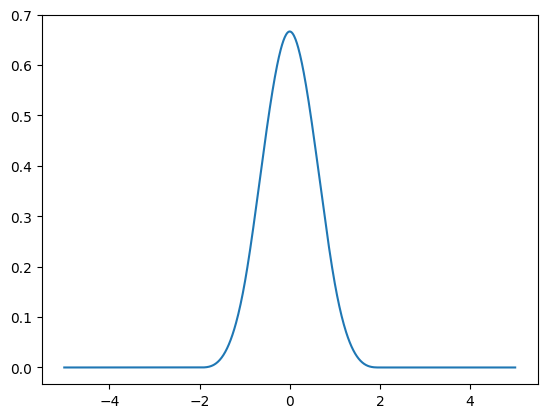

In [15]:
xs = jnp.linspace(-5, 5, 1001)

fig, ax = plt.subplots()
ax.plot(xs, [jitted_bspline_basis(xval) for xval in xs])

In [16]:
h = 0.2
grid = jnp.arange(0, 3 + h / 10, h)

In [17]:
x = 1.25

In [18]:
int(x // h)

6

In [19]:
indices_centered_on = int(x // h) + jnp.arange(-(ORDER + 1) // 2,
                                               (ORDER + 1) // 2 + 1)

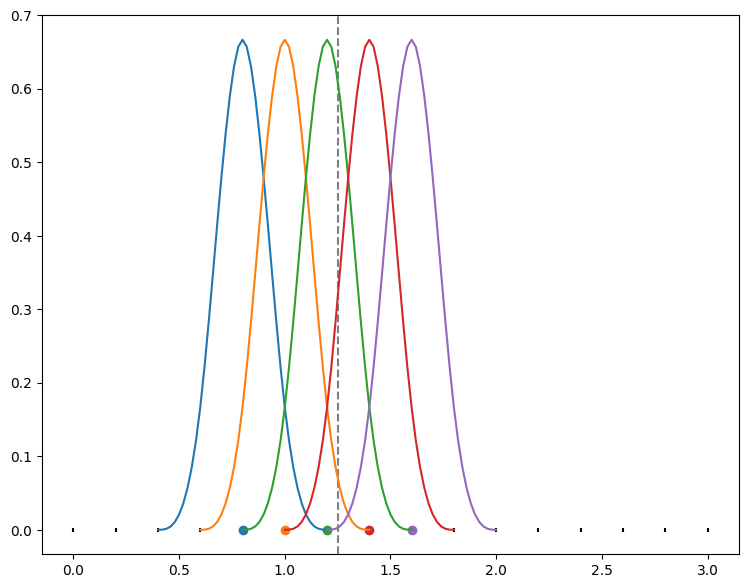

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(grid, onp.zeros_like(grid), s=5, color="black", marker="|")

ax.axvline(x, linestyle="--", color="gray")

for m in indices_centered_on:  # TODO
    x_m = m * h
    splinerange = jnp.linspace((m - (ORDER + 1) / 2) * h,
                               (m + (ORDER + 1) / 2) * h, 41)
    splinevals = jnp.asarray(
        [jitted_bspline_basis((x - x_m) / h) for x in splinerange])
    ax.scatter(x_m, 0)
    ax.plot(splinerange, splinevals)

In [21]:
int(jnp.floor(x / h))

6

In [22]:
int(jnp.ceil(x / h))

7

In [23]:
# x = 8.4
# x = 8.0
# x = 8.1
# x = 0.0

p = ORDER - 1

indices = jnp.arange(jnp.ceil(x / h).astype(int) - p // 2,
                     jnp.ceil(x / h).astype(int) + p // 2)
indices

Array([6, 7], dtype=int64)

In [24]:
def find_ref_index(x):
    ref_index = jnp.ceil(x / h).astype(int)
    return ref_index


vmapped_find_ref_index = jax.vmap(find_ref_index, in_axes=0)


def find_gridpoints_in_splinerange(x):
    ref_index = jnp.ceil(x / h).astype(int)
    return ref_index + jnp.arange(-p // 2, p // 2)


vmapped_find_gridpoints = jax.vmap(find_gridpoints_in_splinerange)

In [25]:
(jnp.asarray([find_gridpoints_in_splinerange(x) for x in
              [-0.1, 0., 0.01, 1.25, 1.8, 2.1, 3.1123, 3.7568, 4.288]]))

Array([[-1,  0],
       [-1,  0],
       [ 0,  1],
       [ 6,  7],
       [ 8,  9],
       [10, 11],
       [15, 16],
       [18, 19],
       [21, 22]], dtype=int64)

In [26]:
rng = onp.random.default_rng(1234)

xs = jnp.array(rng.uniform(0., 10., size=5))
vmapped_find_ref_index(xs)

Array([49, 20, 47, 14, 16], dtype=int64)

In [27]:
rng = onp.random.default_rng(1234)

xs = jnp.array(rng.uniform(0., 10.)).reshape((1,))
vmapped_find_gridpoints(xs)

Array([[48, 49]], dtype=int64)

In [28]:
indices = find_gridpoints_in_splinerange(x)

In [29]:
x, indices

(1.25, Array([6, 7], dtype=int64))

In [30]:
x / h, indices

(6.25, Array([6, 7], dtype=int64))

In [31]:
vmapped_bspline_basis = jax.vmap(bspline_basis_element)

vmapped_bspline_basis(x / h - indices)

Array([0.61197917, 0.31510417], dtype=float64)

In [32]:
bspline_basis_element(x / h)

Array(0., dtype=float64)

In [33]:
rng = onp.random.default_rng(1234)

jitted_find_gridpoints = jax.jit(vmapped_find_gridpoints)

n_particles = 10

for batch_index in tqdm(range(10)):
    xs = jnp.array(rng.uniform(0.5, 2.5, size=n_particles))
    qs = jnp.array(rng.uniform(-1., 1., size=n_particles))
    grid_indices = vmapped_find_gridpoints(xs)

100%|██████████| 10/10 [00:00<00:00, 50.07it/s]


In [34]:
xs.shape, grid_indices.shape

((10,), (10, 2))

In [35]:
vmapped_bspline_basis = jax.vmap(jax.vmap(bspline_basis_element))

dists_on_grid = (xs / h)[:, jnp.newaxis] - grid_indices

spline_values = vmapped_bspline_basis(dists_on_grid)

In [36]:
spline_values.shape

(10, 2)

In [37]:
grid_indices.shape, spline_values.shape

((10, 2), (10, 2))

In [38]:
grid_indices[0], spline_values[0]

(Array([11, 12], dtype=int64), Array([0.66061201, 0.20927076], dtype=float64))

In [39]:
grid_charges = jnp.zeros_like(grid)
grid_charges.at[grid_indices[0]].set(spline_values[0])

Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.66061201, 0.20927076, 0.        , 0.        ,
       0.        ], dtype=float64)

In [40]:
inds = jnp.array([2, 2, 2])
vals = jnp.array([1, 1, 1])

grid_charges = jnp.zeros_like(grid)
grid_charges.at[inds].add(vals)

Array([0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float64)

In [41]:
inds = jnp.array([[2, 2, 2], [3, 3, 3]])
vals = jnp.array([[1, 1, 1], [2, 3, 4]])

grid_charges = jnp.zeros_like(grid)
grid_charges.at[inds].add(vals)

Array([0., 0., 3., 9., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float64)

In [42]:
grid_charges = jnp.zeros_like(grid)
grid_charges = grid_charges.at[grid_indices].add(
    qs[:, jnp.newaxis] * spline_values)

grid_charges

Array([ 0.        ,  0.        ,  0.        , -0.29876446, -0.23213317,
        0.28349635,  0.16951326, -0.30560161, -0.06045217,  0.032483  ,
       -0.41184672,  0.17238978, -0.26163154, -0.3494836 ,  0.        ,
        0.        ], dtype=float64)

In [43]:
grid_charges.sum()

Array(-1.26203087, dtype=float64)

In [44]:
qs.sum()

Array(-1.34295649, dtype=float64)

## More systematically

In [45]:
def make_compute_gridcharge_1d(grid: GridAxis1D):
    vmapped_find_grid_indices = jax.vmap(grid.find_grid_indices_in_splinerange)
    vmapped_bspline_basis = jax.vmap(jax.vmap(bspline_basis_element))

    def compute_gridcharge_1d(positions_1d, charges):
        grid_indices = vmapped_find_grid_indices(positions_1d)

        # TODO: I think the first part (`(positions_1d / grid.h)[:, jnp.newaxis]`
        #  needs to be shifted (like `process_raw_indices`)
        # distances_on_grid = (positions_1d / grid.h)[:, jnp.newaxis] - grid_indices
        # TODO: something like the following (but smarter) (the 2 comes from p // 2)
        distances_on_grid = ((positions_1d / grid.h)[:,
                             jnp.newaxis] + 2) - grid_indices
        spline_values = vmapped_bspline_basis(distances_on_grid)

        gridcharge = jnp.zeros(grid.n_total)
        gridcharge = gridcharge.at[grid_indices].add(
            charges[:, jnp.newaxis] * spline_values)

        return gridcharge

    return compute_gridcharge_1d

In [46]:
def make_anterpolation_function(grid: GridAxis1D):
    vmapped_find_grid_indices = jax.vmap(grid.find_grid_indices_in_splinerange)
    vmapped_bspline_basis = jax.vmap(jax.vmap(bspline_basis_element))

    def anterpolate(positions_1d, charges):
        pos_divided_by_h = positions_1d / grid.h

        grid_indices = vmapped_find_grid_indices(positions_1d)

        # TODO: I think the first part (`(positions_1d / grid.h)[:, jnp.newaxis]`
        #  needs to be shifted (like `process_raw_indices`)
        # distances_on_grid = (positions_1d / grid.h)[:, jnp.newaxis] - grid_indices
        # TODO: something like the following (but smarter) (the 2 comes from p // 2)
        distances_on_grid = ((positions_1d / grid.h)[:,
                             jnp.newaxis] + 2) - grid_indices
        spline_values = vmapped_bspline_basis(distances_on_grid)

        gridcharge = jnp.zeros(grid.n_total)
        gridcharge = gridcharge.at[grid_indices].add(
            charges[:, jnp.newaxis] * spline_values)

        return gridcharge

    return anterpolate

In [47]:
length = 10.
h = 0.25

# grid = set_up_grid_axis(length=length, h=h, p=ORDER-1)
grid = set_up_grid_axis(length=length, h=h,
                        p=ORDER)  # TODO: ORDER or ORDER - 1?

compute_gridcharge = make_compute_gridcharge_1d(grid)
jitted_compute_gridcharge = jax.jit(compute_gridcharge)

ValueError: p must be even

In [ ]:
n_particles = 1

rng = onp.random.default_rng(1234)
positions = jnp.array(rng.uniform(0.0, length, size=n_particles))
charges = jnp.array(rng.uniform(-1., 1., size=n_particles))

print("- Call to trigger compilation")
gridcharge = jitted_compute_gridcharge(positions, charges)
print("- Second call")
gridcharge = jitted_compute_gridcharge(positions, charges)

In [ ]:
gridcharge

In [ ]:
gridcharge.sum()

In [ ]:
charges.sum()

In [ ]:
grid.h

In [48]:
vmapped_bspline_basis(jnp.array([[-2, -1, 0, 1, 2]]))

Array([[0.        , 0.16666667, 0.66666667, 0.16666667, 0.        ]],      dtype=float64)

In [80]:
x = 8.4
h = 1.0

reference_index = jnp.ceil(x / h).astype(int)
raw_indices = reference_index + jnp.arange(-(ORDER + 1) // 2,
                                           (ORDER + 1) // 2)

# reference_index = jnp.ceil(x / h - 0.5).astype(int)
# raw_indices = reference_index + jnp.arange(-(ORDER + 1) // 2,
#                                            (ORDER + 1) // 2 + 1)

In [81]:
raw_indices

Array([ 7,  8,  9, 10], dtype=int64)

In [82]:
jnp.array(x / h) - raw_indices

Array([ 1.4,  0.4, -0.6, -1.6], dtype=float64, weak_type=True)

In [83]:
bspline_basis_element(x / h - 6)

Array(0., dtype=float64)

In [84]:
vmapped_bspline_basis((jnp.array(x / h) - raw_indices)[jnp.newaxis, :])

Array([[0.036     , 0.53866667, 0.41466667, 0.01066667]], dtype=float64)

In [85]:
vmapped_bspline_basis((jnp.array(x / h) - jnp.arange(20))[jnp.newaxis, :])

Array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.036     , 0.53866667, 0.41466667,
        0.01066667, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]],      dtype=float64)

In [66]:
h

1.0

In [67]:
bspline_basis_element

functools.partial(<function evaluate_basis_element at 0x7f42bff63310>, Array([-2., -1.,  0.,  1.,  2.], dtype=float64))

In [68]:
bspline_basis_element(0), bspline_basis_element(-1.e-2), bspline_basis_element(
    1.e-2)

(Array(0.66666667, dtype=float64),
 Array(0.66656717, dtype=float64),
 Array(0.66656717, dtype=float64))

In [69]:
bspline_basis_element(-2.5), bspline_basis_element(2.5)

(Array(0., dtype=float64), Array(0., dtype=float64))

In [70]:
create_bspline_basis_element(ORDER)

functools.partial(<function evaluate_basis_element at 0x7f42bff63310>, Array([-2., -1.,  0.,  1.,  2.], dtype=float64))